In [1]:
import meep as mp
import meep.adjoint as mpa
import autograd.numpy as npa
from autograd import tensor_jacobian_product
import numpy as np
import nlopt
from matplotlib import pyplot as plt
from icecream import ic

from gradoptest import get_opt
from utils import normalise, mirror_upper_y_half, smooth_image


In [2]:
pml_size = 1.0  # (μm)

dx = 0.02
opt_size_x = 101 * dx
opt_size_y = 181 * dx
size_x = 2.6 + pml_size  # um
size_y = 4.5 + pml_size  # um
out_wg_dist = 1.25
wg_width = 0.5
mode_width = 3*wg_width
wg_index = 2.8
bg_index = 1.44

source_x = -size_x/2 - 0.1
source_y = 0
source_yspan = mode_width
source_z = 0
# source_zspan = 1
center_wavelength = 1.550

# seed = 240
# np.random.seed(seed)
mp.verbosity(0)
# Effective permittivity for a Silicon waveguide with a thickness of 220nm
Si = mp.Medium(index=wg_index)
SiO2 = mp.Medium(index=bg_index)
# size of a pixel (in μm) 20 nm in lumerical exp
delta = dx
# resolution = 20 # (pixels/μm)
resolution = 1/delta  # pixels/μm
waveguide_width = wg_width  # 0.5 # (μm)
design_region_width = opt_size_x  # (μm)
design_region_height = opt_size_y  # (μm)
# 1.0 (μm) distance between arms center to center
arm_separation = out_wg_dist
# waveguide_length = source_wg_xmax - source_wg_xmin  # 0.5 (μm)

# ## Design variable setup

minimum_length = 0.09  # (μm)
eta_e = 0.75
filter_radius = mpa.get_conic_radius_from_eta_e(
    minimum_length, eta_e)  # (μm)
eta_i = 0.5
# eta_d = 1-eta_e
# int(4*resolution) # (pixels/μm)
design_region_resolution = int(resolution)
frequencies = 1/np.linspace(1.5, 1.6, 5)  # (1/μm)

Nx = int(design_region_resolution*design_region_width)
Ny = int(design_region_resolution*design_region_height)

design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), SiO2, Si)
size = mp.Vector3(design_region_width, design_region_height)
volume = mp.Volume(center=mp.Vector3(), size=size)
design_region = mpa.DesignRegion(design_variables, volume=volume)

# ## Simulation Setup

Sx = 2*pml_size + size_x  # cell size in X
Sy = 2*pml_size + size_y  # cell size in Y
cell_size = mp.Vector3(Sx, Sy)

pml_layers = [mp.PML(pml_size)]

fcen = 1/center_wavelength  # 1/1.55
width = 0.2
fwidth = width * fcen
source_center = [source_x, source_y, source_z]

source_size = mp.Vector3(0, source_yspan, 0)
kpoint = mp.Vector3(1, 0, 0)
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.EigenModeSource(src,
                                eig_band=1,
                                direction=mp.NO_DIRECTION,
                                eig_kpoint=kpoint,
                                size=source_size,
                                center=source_center,
                                eig_parity=mp.EVEN_Z+mp.ODD_Y)]
# mon_pt = mp.Vector3(*source_center)

geometry = [
    # left waveguide
    mp.Block(center=mp.Vector3(x=-Sx/4),
                material=Si,
                size=mp.Vector3(Sx/2+1, waveguide_width, 0)),
    # top right waveguide
    mp.Block(center=mp.Vector3(x=Sx/4, y=arm_separation),
                material=Si,
                size=mp.Vector3(Sx/2+1, waveguide_width, 0)),
    # bottom right waveguide
    mp.Block(center=mp.Vector3(x=Sx/4, y=-arm_separation),
                material=Si,
                size=mp.Vector3(Sx/2+1, waveguide_width, 0)),
    mp.Block(center=design_region.center,
                size=design_region.size,
                material=design_variables)
]

sim = mp.Simulation(cell_size=cell_size,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=source,
                    symmetries=[mp.Mirror(direction=mp.Y, phase=-1)],
                    default_material=SiO2,
                    resolution=resolution,
                    force_all_components=True)

size = mp.Vector3(Sx, Sy, 0)
monsize = mp.Vector3(y=3*waveguide_width)
source_mon_center = mp.Vector3(x=source_x + 0.1)
top_mon_center = mp.Vector3(size_x/2, arm_separation, 0)
# source_fluxregion = mp.FluxRegion(center=source_mon_center,
#                                   size=monsize,
#                                   weight=-1)
# top_fluxregion = mp.FluxRegion(center=top_mon_center,
#                                size=monsize,
#                                weight=-1)

# abs_src_coeff = 57.97435797757672

# Get top output flux coefficients
topmoncenter = mp.Vector3(size_x/2, arm_separation, 0)
# topfluxregion = mp.FluxRegion(topmoncenter, monsize)

mode = 1

volume = mp.Volume(center=topmoncenter, size=monsize)
ob_list = [mpa.EigenmodeCoefficient(sim, volume, mode)]

# -------
monsize = monsize = mp.Vector3(y=3*waveguide_width)
source_mon_center = mp.Vector3(x=source_x + 0.1)
TE0 = mpa.EigenmodeCoefficient(sim,
                                mp.Volume(center=source_mon_center,
                                            size=monsize), mode)
top_mon_center = mp.Vector3(size_x/2, arm_separation, 0)
TE_top = mpa.EigenmodeCoefficient(sim,
                                    mp.Volume(center=top_mon_center,
                                            size=monsize), mode)

bot_mon_center = mp.Vector3(size_x/2, -arm_separation, 0)
TE_bottom = mpa.EigenmodeCoefficient(sim,
                                        mp.Volume(center=bot_mon_center,
                                                size=monsize), mode)
ob_list = [TE0, TE_top, TE_bottom]

# def J(top):
#     return npa.mean(npa.abs(top)**2)

def J(source, top, bottom):
    power = npa.abs(top/source) ** 2 + npa.abs(bottom/source) ** 2
    return npa.mean(power)

opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=J,
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies
)

sim_args = {"Nx": Nx, "Ny": Ny,
            "Sx": Sx, "Sy": Sy,
            "fcen": fcen,
            "filter_radius": filter_radius,
            "design_region_width": design_region_width,
            "design_region_height": design_region_height,
            "design_region_resolution": design_region_resolution,
            "eta_i": eta_i}

In [3]:
size = mp.Vector3(Sx, Sy, 0)

dft_monitor = sim.add_dft_fields(
    [mp.Ex, mp.Ey, mp.Ez],             # Components to monitor
    fcen, 0, 1,
    # frequency=fcen,                     # Operating frequency
    center=mp.Vector3(0, 0, 0),        # Center of the monitor region
    size=size          # Size of the monitor region
)

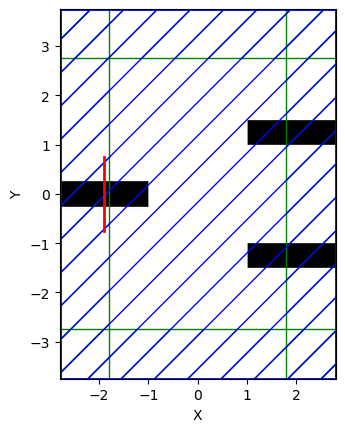

In [4]:
opt.plot2D()

In [5]:
def mapping(x,eta,beta):
    x = (npa.fliplr(x.reshape(Nx,Ny)) + x.reshape(Nx,Ny))/2 # up-down symmetry
    
    # filter
    filtered_field = mpa.conic_filter(x,
        filter_radius,design_region_width,design_region_height,design_region_resolution)
    
    # projection
    projected_field = mpa.tanh_projection(filtered_field,beta,eta)
    
    # interpolate to actual materials
    return projected_field.flatten()

In [6]:
# x0 = 0.5*np.ones((Nx,Ny))
# f0, g0 = opt([mapping(x0,0.5,2)])

In [7]:
# plt.figure()
# print(g0.shape)
# plt.imshow(np.rot90(g0[:,0].reshape(Nx,Ny)))
# plt.colorbar()

In [8]:

# backprop_gradient = tensor_jacobian_product(mapping,0)(x0,0.5,2,g0[:,0])
# plt.imshow(np.rot90(backprop_gradient.reshape(Nx,Ny)))
# plt.colorbar()

In [9]:
def f(v, gradient, cur_beta):
    print("Current iteration: {}".format(cur_iter[0]+1))
    
    f0, dJ_du = opt([mapping(v,eta_i,cur_beta)])
    
    plt.subplot(1,2,1)
    ax = plt.gca()
    opt.plot2D(False,ax=ax,plot_sources_flag=False,plot_monitors_flag=False,plot_boundaries_flag=False)
    ax.axis('off')

    
    if gradient.size > 0:
        gradient[:] = tensor_jacobian_product(mapping,0)(v,eta_i,cur_beta,np.sum(dJ_du,axis=1))
    
    evaluation_history.append(np.max(np.real(f0)))
    cur_iter[0] = cur_iter[0] + 1

    # Debugging bits
    #------------------
    ic(f0)
    ic(gradient.min(), gradient.max(), gradient.mean())
    plt.subplot(1,3,2)
    plt.imshow(np.rot90(gradient.reshape(Nx,Ny)))
    plt.title('gradient')
    # plt.colorbar()
    plt.axis('off')


    sim.run(until_after_sources=100)
 
    ic(dft_monitor)
    Ex = sim.get_dft_array(dft_monitor, mp.Ex, 0)
    Ex = np.real(Ex)
    ic(Ex.min(), Ex.max(), np.abs(Ex).mean())
    plt.subplot(1,3,3)
    plt.imshow(np.rot90(Ex), vmin=Ex.min(), vmax=Ex.max())
    plt.title('real x field')
    plt.axis('off')
    plt.show()
    #------------------
    
    return np.real(f0)

current beta:  4
Current iteration: 1
Starting forward run...
Starting adjoint run...
Calculating gradient...


ic| f0: 0.06269110710691095
ic| gradient.min(): -0.0009334873383076479
    gradient.max(): 0.0005297157943201324
    gradient.mean(): -5.6659293688916964e-05
ic| dft_monitor: <meep.simulation.DftFields object at 0x7f1c3cfb4910>


ValueError: Invalid type of dft object: None

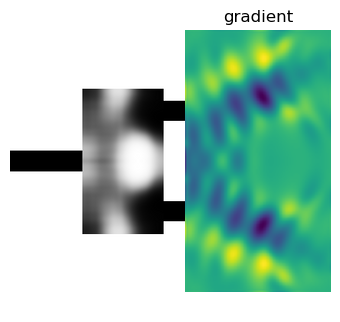

In [10]:
evaluation_history = []
cur_iter = [0]
algorithm = nlopt.LD_MMA
n = Nx * Ny # number of parameters

# Initial guess
x = np.random.rand(Nx, Ny)
x = normalise(mirror_upper_y_half(smooth_image(x))).flatten()

# lower and upper bounds
lb = 0
ub = 1

cur_beta = 4
beta_scale = 2
num_betas = 6
update_factor = 12
for iters in range(num_betas):
    print("current beta: ",cur_beta)
    
    solver = nlopt.opt(algorithm, n)
    solver.set_lower_bounds(lb)
    solver.set_upper_bounds(ub)
    solver.set_max_objective(lambda a,g: f(a,g,cur_beta))
    solver.set_maxeval(update_factor)
    x[:] = solver.optimize(x)
    cur_beta = cur_beta*beta_scale

## Final device evaluation

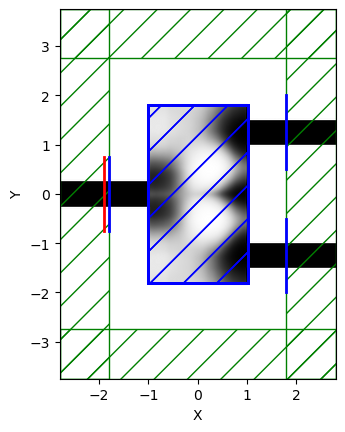

In [ ]:
opt.plot2D(True)

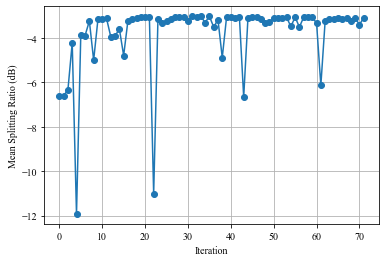

In [ ]:
plt.figure()
plt.plot(10*np.log10(0.5*np.array(evaluation_history)),'o-')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Mean Splitting Ratio (dB)')
plt.show()

In [ ]:
f0, dJ_du = opt([mapping(x,eta_i,cur_beta)],need_gradient = False)
frequencies = opt.frequencies
source_coef, top_coef, bottom_ceof = opt.get_objective_arguments()

top_profile = np.abs(top_coef/source_coef) ** 2
bottom_profile = np.abs(bottom_ceof/source_coef) ** 2

Starting forward run...


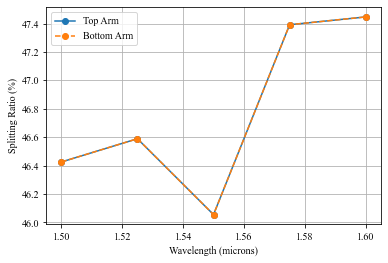

In [ ]:
plt.figure()
plt.plot(1/frequencies,top_profile*100,'-o' ,label = 'Top Arm')
plt.plot(1/frequencies,bottom_profile*100,'--o',label = 'Bottom Arm')
plt.legend()
plt.grid(True)
plt.xlabel('Wavelength (microns)')
plt.ylabel('Splitting Ratio (%)')
#plt.ylim(46.5,50)
plt.show()